# mSSA Run

## Importing Packages

In [2]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
sys.path.append('/mnt/home/ktavangar/projects/MSSA_Snails/code/')
import importlib
import helper

In [3]:
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

plt.rcParams.update({
    'axes.linewidth': 2,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    "lines.color": "white",
    "patch.edgecolor": "white",
    "text.color": "black",
    "axes.facecolor": "white",
    "axes.edgecolor": "lightgray",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "grid.color": "lightgray",
    "figure.facecolor": "white",
    "figure.edgecolor": "white",
    "savefig.facecolor": "white",
    "savefig.edgecolor": "white"})

## Loading In Files

In [4]:
directory = '/mnt/home/ktavangar/ceph/...'

fname_m0_amp = directory+'m0_amp_bins_j30_t16.dat'

fname_m1_amp = directory+'m1_amp_bins_j30_t16.dat'
fname_m1_pitch = directory+'m1_pitch_bins_j30_t16.dat'
fname_m1_rel_amp = directory+'m1_amp_rel_bins_j30_t16.dat'

fname_m2_amp = directory+'m2_amp_bins_j30_t16.dat'
fname_m2_pitch = directory+'m2_pitch_bins_j30_t16.dat'
fname_m2_rel_amp = directory+'m2_amp_rel_bins_j30_t16.dat'



coefs_m1_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m1_rel_amp)
coefs_m1_pitch0 = pyEXP.coefs.Coefs.factory(fname_m1_pitch)
coefs_m2_rel_amp0 = pyEXP.coefs.Coefs.factory(fname_m2_rel_amp)
coefs_m2_pitch0 = pyEXP.coefs.Coefs.factory(fname_m2_pitch)

coefs_m1_rel_amp = coefs_m1_rel_amp0.deepcopy()
coefs_m1_pitch = coefs_m1_pitch0.deepcopy()
coefs_m2_rel_amp = coefs_m2_rel_amp0.deepcopy()
coefs_m2_pitch = coefs_m2_pitch0.deepcopy()

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData
---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [5]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m_pitch.getAllCoefs()))
times = coefs_m_pitch.Times()

keylst_m1_amp = [[i] for i in range(n_channels)]
keylst_m1_pitch = [[i] for i in range(n_channels)]
keylst_m2_amp = [[i] for i in range(n_channels)]
keylst_m2_pitch = [[i] for i in range(n_channels)]

config = {"snails_m1_amp_rel": (coefs_m_rel_amp, keylst_m_amp, []),
#          "snails_m1_pitch": (coefs_m_pitch, keylst_m_pitch, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 128 threads


## mSSA Analysis

In [ ]:
fig_dir = '/mnt/home/ktavangar/projects/MSSA_Snails/figures/.../'

In [6]:
ev = mssa.eigenvalues()

shape U = 148800 x 30


In [7]:
coefs_m_rel_amp.zerodata()
coefs_m_pitch.zerodata()
mssa.reconstruct([*range(30)])

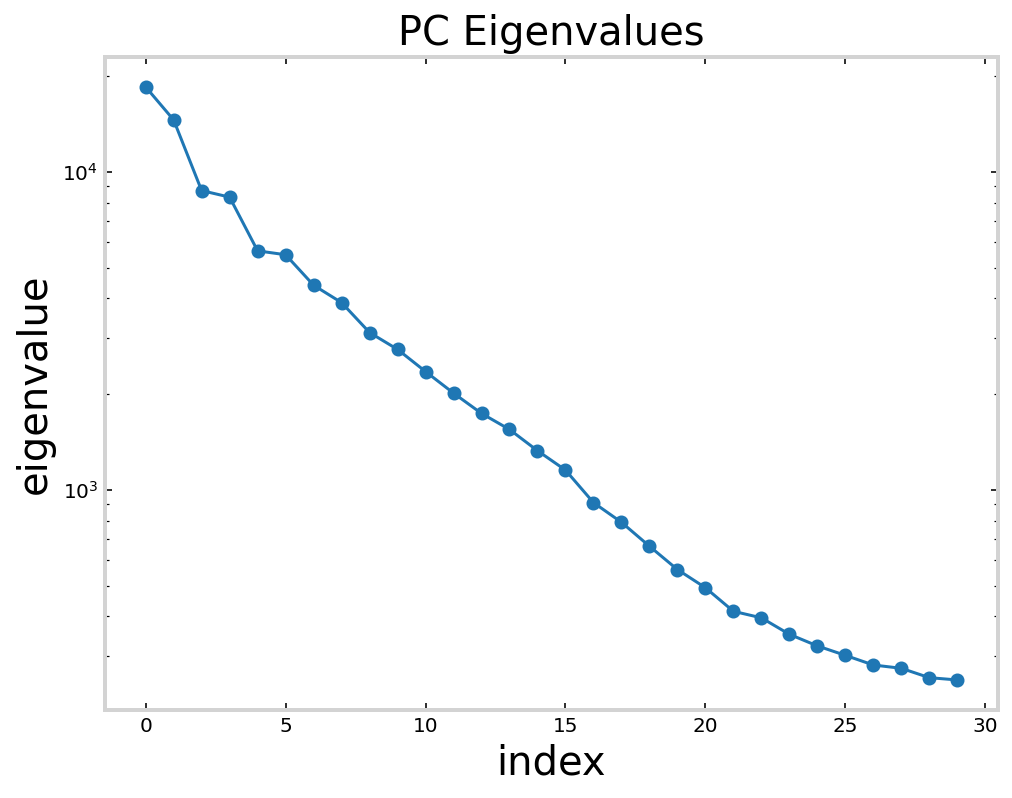

In [8]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev, '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

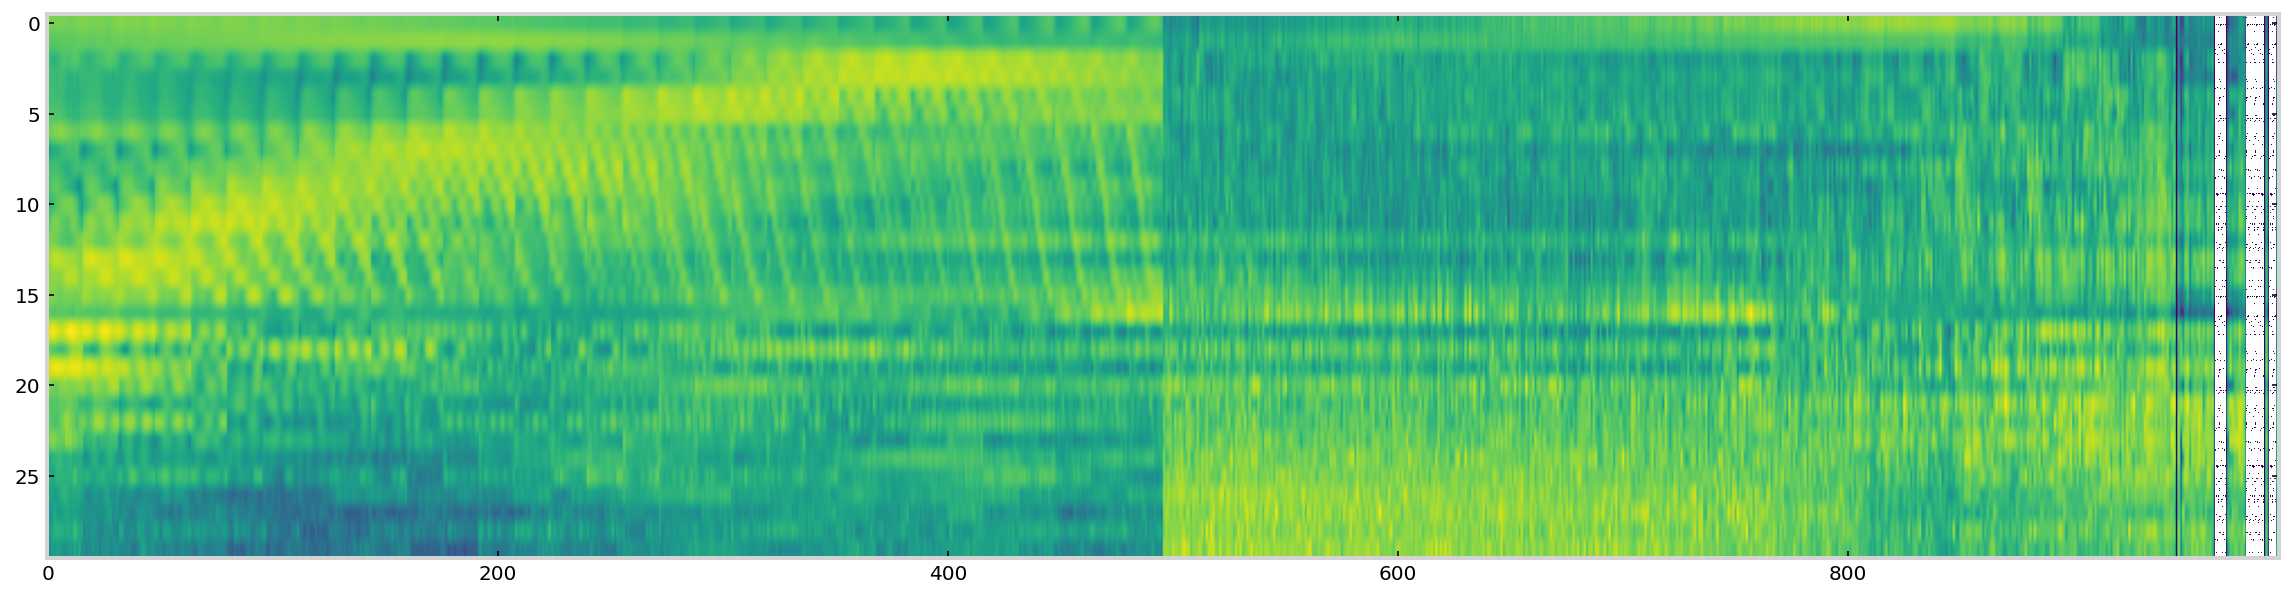

In [9]:
t1, t2 = mssa.contrib()
plt.figure(figsize=(20, 5))
plt.imshow(t2, aspect='auto', norm=mpl.colors.LogNorm())

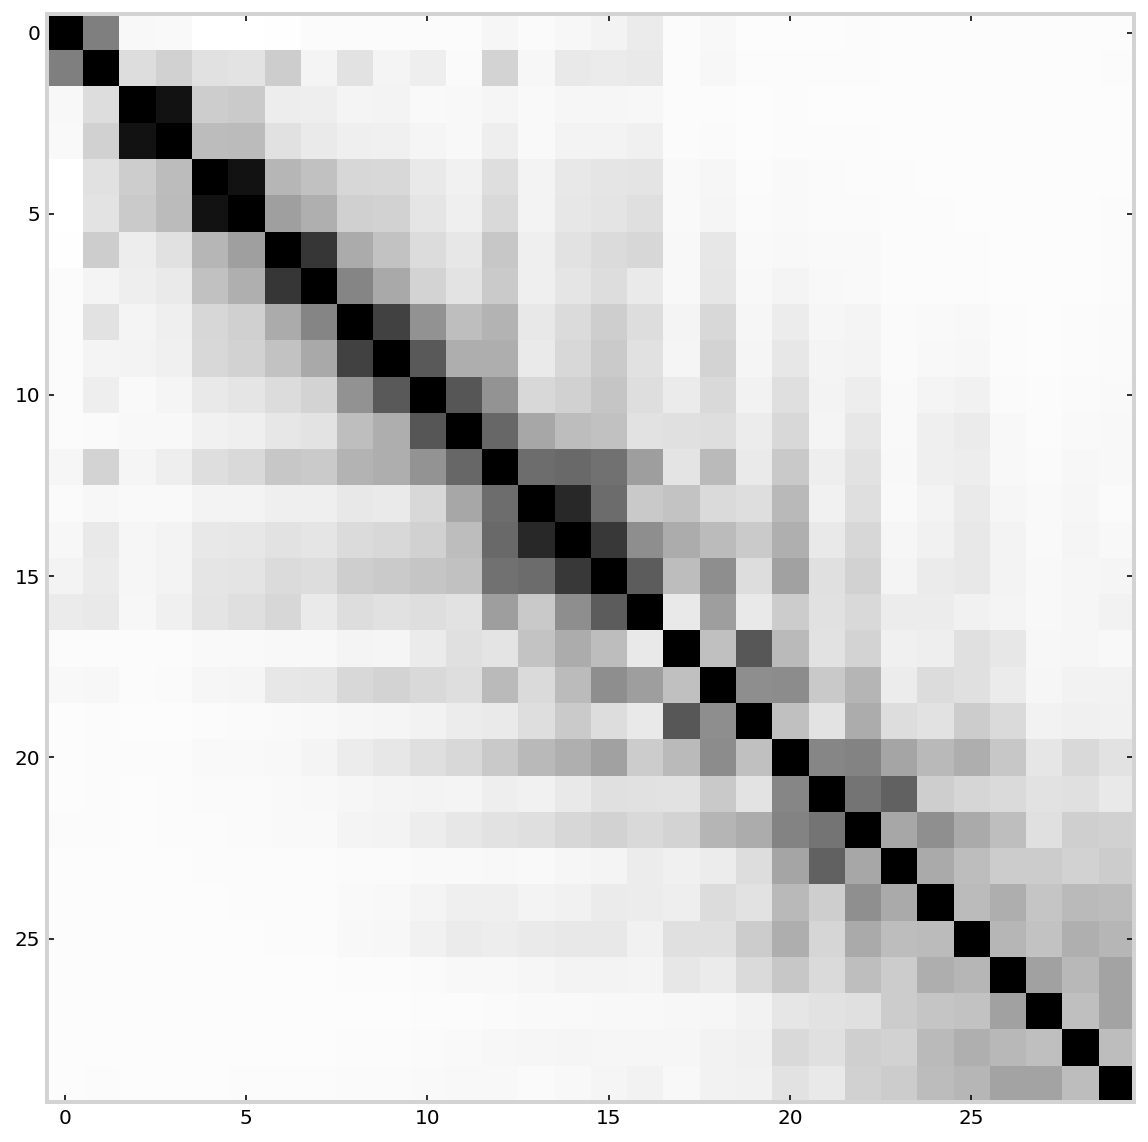

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

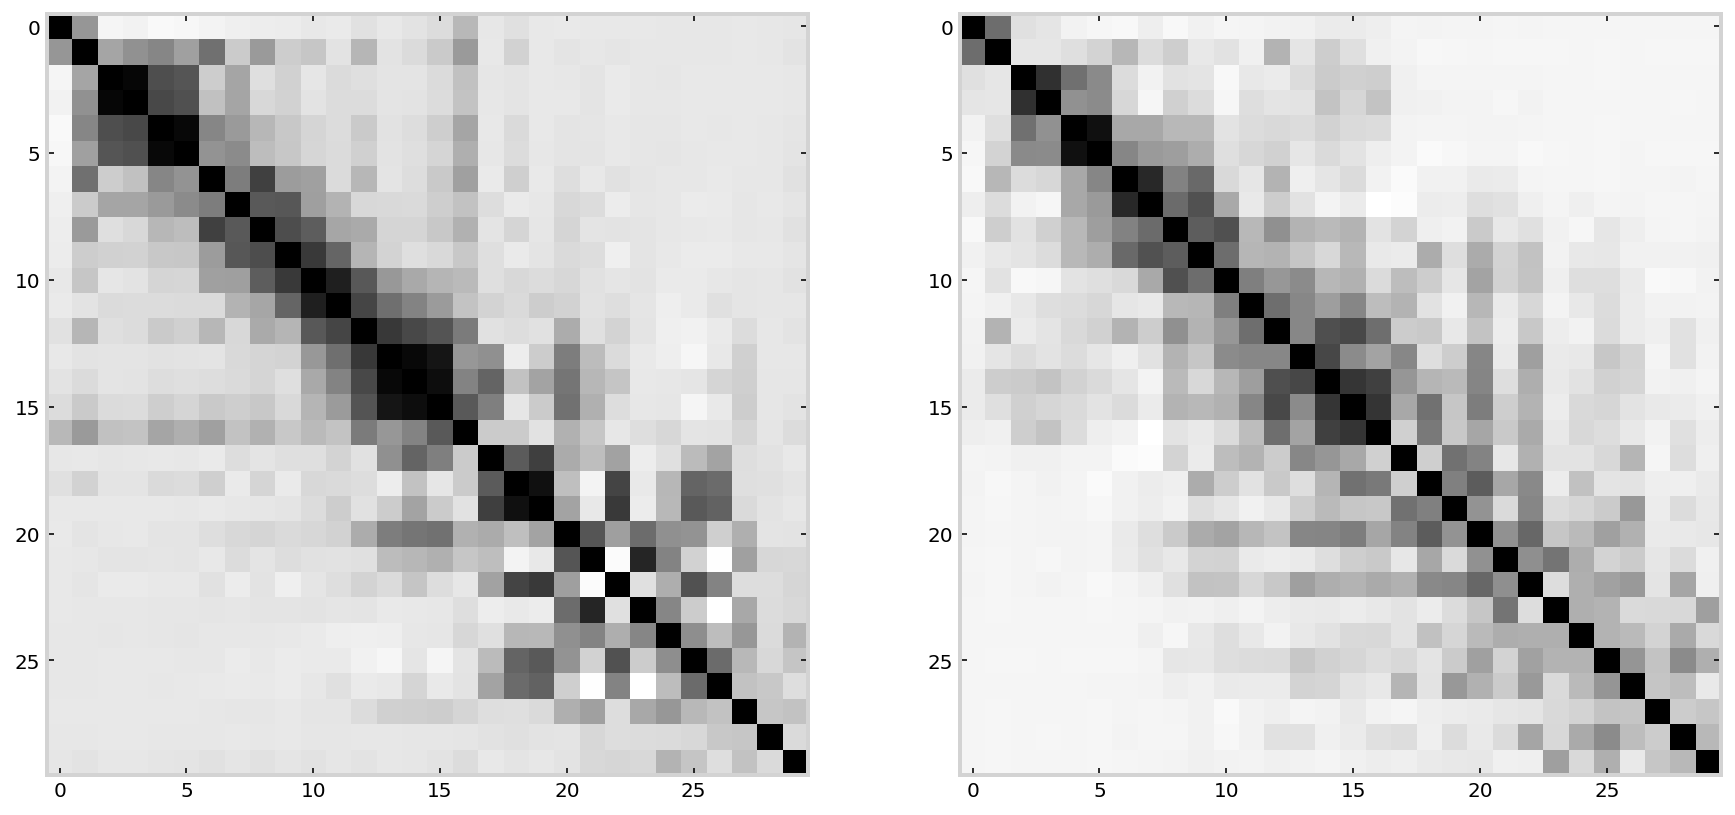

In [11]:
# wCorr for amplitude:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(15,7))
ax1.imshow(mssa.wCorrKey([0]), cmap='gray_r')
ax2.imshow(mssa.wCorrKey([1]), cmap='gray_r')
plt.show()

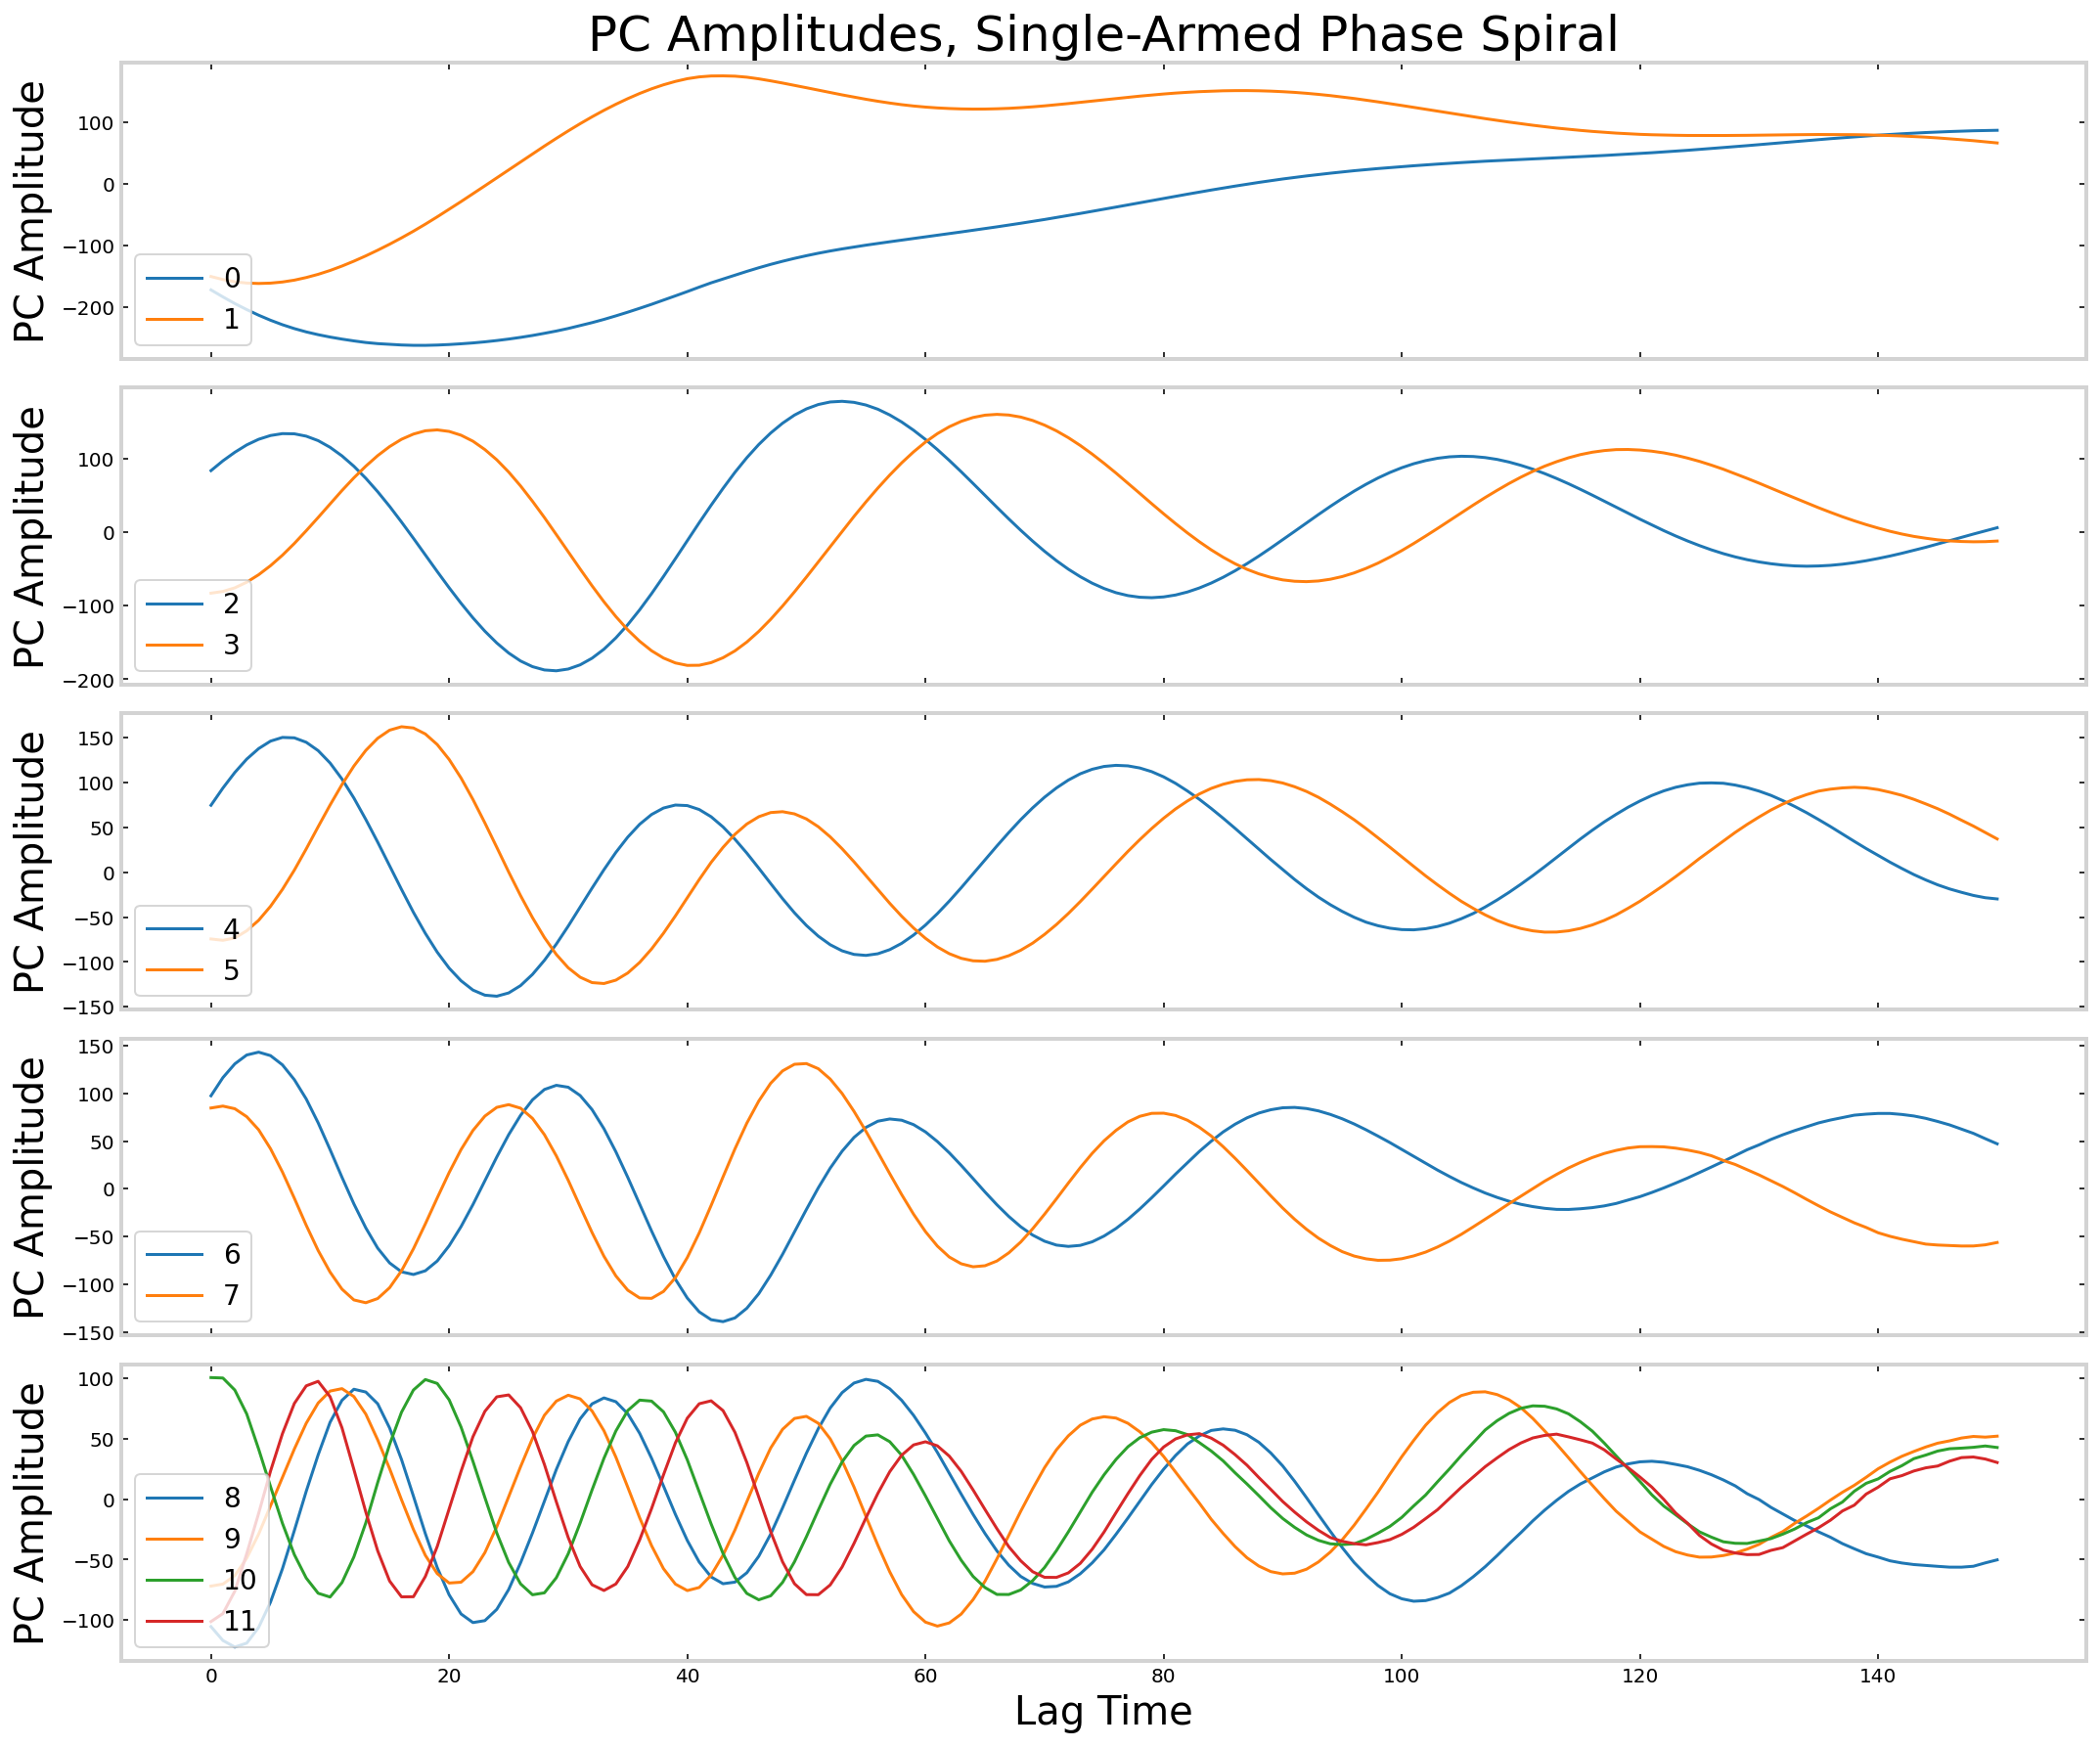

In [12]:
%matplotlib inline
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(15, 2.5*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

plt.suptitle('PCs, ...-Armed Phase Spiral ...', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

for i in range(n_plots):
    axs[i].set_ylabel('PC Amplitude', fontsize=20)
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

In [ ]:
freq, power = mssa.pcDFT()
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(25, 8))

color = iter(cm.rainbow(np.linspace(0, 1, 11)))
    
for i in range(0, 11,1):
    c = next(color)
    ax1.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

    if i>=2:
        ax2.plot(freq[:20] * (1/0.009778)/(2*np.pi), power[:20,i], '-o', c=c, label='pc'+str(i))

ax1.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax2.set_xlabel('Frequency [1/Gyr]', fontsize=20)
ax1.legend() ; ax2.legend(fontsize=18)
ax1.set_ylabel('Power', fontsize=20)
ax1.set_yscale('log')

plt.suptitle('...-Armed ... Power Spectra', fontsize=25)
fig.tight_layout()
#plt.savefig(fig_dir+'power_spectrum.pdf')
plt.show()

## Face-on Plots

In [ ]:
importlib.reload(sys.modules['helper'])
from helper import *

tbl_pitch = np.loadtxt(directory+'m_pitch_bins_j30_t16.dat')
tbl_rel_amp = np.loadtxt(directory+'m_amp_rel_bins_j30_t16.dat')

f = fig_dir+'face-on_plots/data.mp4'
f_sub = fig_dir+'face-on_plots/data_subtract_pc0-1.mp4'

MakeAnim = MakeAnimations(mssa, '...', times, n_channels, [0,1])
MakeAnim.make_pre_mssa_face_on(f, tbl_rel_amp, tbl_pitch)
MakeAnim.make_pre_mssa_face_on_subtracted(f_sub, tbl_rel_amp, tbl_pitch)

In [ ]:
importlib.reload(sys.modules['helper'])
from helper import *

f = fig_dir+'face-on_plots/pc0+pc1.mp4'
MakeAnim0 = MakeAnimations(mssa, '...', times, n_channels, [0,1])
MakeAnim0.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc2+pc3.mp4'
MakeAnim1 = MakeAnimations(mssa, '...', times, n_channels, [2,3])
MakeAnim1.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc4+pc5.mp4'
MakeAnim2 = MakeAnimations(mssa, '...', times, n_channels, [4,5])
MakeAnim2.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc6+pc7.mp4'
MakeAnim3 = MakeAnimations(mssa, '...', times, n_channels, [6,7])
MakeAnim3.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc8-15.mp4'
MakeAnim4 = MakeAnimations(mssa, '...', times, n_channels, list(range(8,16)))
MakeAnim4.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc0-4.mp4'
MakeAnim5 = MakeAnimations(mssa, '...', times, n_channels, list(range(4)))
MakeAnim5.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc2-8.mp4'
MakeAnim5 = MakeAnimations(mssa, '...', times, n_channels, list(range(2,8)))
MakeAnim5.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc0-8.mp4'
MakeAnim6 = MakeAnimations(mssa, '...', times, n_channels, list(range(8)))
MakeAnim6.make_recon_mov_disk_plot(f)

f = fig_dir+'face-on_plots/pc0-16.mp4'
MakeAnim7 = MakeAnimations(mssa, '...', times, n_channels, list(range(16)))
MakeAnim7.make_recon_mov_disk_plot(f)

### Re-winding to a "Dipole"

In [ ]:
# To get colorbar
jphi_c = np.linspace(1000, 4000, 30+1) # MIGHT NEED TO CHANGE
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

In [ ]:
# Take Reconstructions

mssa.reconstruct(list(range(2,10)))
get_recon = mssa.getReconstructed()

recon_amp_ = get_recon[list(get_recon.keys())[0]].getAllCoefs()
recon_amp = recon_amp_ - np.mean(recon_amp_, axis=0)

recon_pitch_ = get_recon[list(get_recon.keys())[1]].getAllCoefs()
recon_pitch = recon_pitch_ - np.mean(recon_pitch_, axis=0)

# what is omega_phi at each radius, in rad/Gyr?
freqs = np.load('/mnt/home/ktavangar/projects/MSSA_Snails/code/frequency_array_j30.npy')
omega_phi = freqs*2*np.pi

time_diff = times[1]-times[0]

In [ ]:
def shearing_box_hack(timestep, reconstruction, omega_phi, coef_times, axs, rewind_time):
    
    ax1, ax2 = axs
    ax1.clear() ; ax2.clear()
    
    t = timestep # IS THIS CORRECT
    
    rad_mean_amp = np.mean(np.reshape(reconstruction[:,t], (16,31), 'F'), axis=0)

    #plot what that timestep looks like after subtracting background
    
    # amplitude
    im1 = ax1.pcolormesh(T, J, reconstruction[:,t].reshape((31, 16)).T - rad_mean_amp, cmap='RdBu_r', 
               norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')
    # pitch angle
    # im1 = ax1.pcolormesh(T, J, reconstruction[:,t].reshape((21, 16)).T - rad_mean_amp, cmap='RdBu_r', 
    #            norm=mpl.colors.SymLogNorm(linthresh=0.1, vmax=1, vmin=-1), shading='nearest')
    

    # how far has each region traveled since the time of interaction?
    time_elapsed = t*time_diff - rewind_time
    d_rot = time_elapsed*omega_phi

    #now interpolate at each radius so that I can use the same grid as before
    interp = scipy.interpolate.interp1d(tphi_c, reconstruction[:,t].reshape((31, 16)), axis=1, 
                                        fill_value="extrapolate")
    all_interp = interp((T+d_rot)%(2*np.pi))
    past_grid = np.diagonal(all_interp, axis1=0, axis2=2)

    #plot what that timestep looks like after subtracting background
    #AMPLITUDE
    im2 = ax2.pcolormesh(T, J, past_grid - rad_mean_amp, cmap='RdBu_r', 
                    norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')
    #PITCH ANGLE
    # im2 = ax2.pcolormesh(T, J, past_grid - rad_mean_amp, cmap='RdBu_r', 
    #                 norm=mpl.colors.SymLogNorm(linthresh=0.1, vmax=1, vmin=-1), shading='nearest')
    #plt.colorbar(im2, ax=ax2)
    #ax2.plot([sgr_ang_at_impact+np.pi,sgr_ang_at_impact], [4000,4000], c='k', ls='dashed')
    
    ax1.text(3*np.pi/2, 100, r'{} Gyr'.format(np.around((coef_times[0]+t)*0.01, 2)), fontsize=20, 
            ha="center", c='k')
    ax2.text(3*np.pi/2, 100, r'{} Gyr'.format(np.around((coef_times[0]+t)*0.01, 2)), fontsize=20, 
            ha="center", c='k')
    
    ax1.set_title('...-armed ..., PC2-9 Contribution', fontsize=25)
    ax2.set_title('Re-winding Approximation', fontsize=25)
    plt.draw()
    
def shearing_box_movie(reconstruction, omega_phi, coef_times, filename):
    fig, axs = plt.subplots(1, 2, figsize=(18, 8), subplot_kw={'projection': 'polar'})
    
    #fig.tight_layout()
    
    anim = FuncAnimation(
        fig,
        partial(shearing_box_hack, reconstruction=reconstruction, omega_phi=omega_phi, 
                coef_times=coef_times, axs=axs, rewind_time=0.35),
        frames=np.arange(0, int(len(coef_times)), 1),
        interval=2,
        blit=False,
    )
    FFwriter = animation.FFMpegWriter(fps=10)
    anim.save(filename, writer = FFwriter)

In [ ]:
filename = fig_dir+'face-on_plots/pc2-9_rewinding_..._inttime....mp4'
shearing_box_movie(recon_amp, omega_phi, times, filename)

### Predict Dipole Evolution

In [ ]:
t=... #timesteps
dipole_timestep = ...


rad_mean_amp_dipole = np.mean(np.reshape(recon_amp[:,dipole_timestep], (16,31), 'F'), axis=0)
rad_mean_amp_future = np.mean(np.reshape(recon_amp[:,t], (16,31), 'F'), axis=0)

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(25, 7), subplot_kw={'projection': 'polar'})

im1 = ax1.pcolormesh(T, J, recon_amp[:,dipole_timestep].reshape((31, 16)).T - rad_mean_amp_dipole, 
                     cmap='RdBu_r', 
                     norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')


time_elapsed = t*time_diff - dipole_timestep*0.01
d_rot = time_elapsed* (200*1.02268944*200 / jphi_c)

#now interpolate at each radius so that I can use the same grid as before
interp = scipy.interpolate.interp1d(tphi_c, recon_amp[:,dipole_timestep].reshape((31, 16)), axis=1, 
                                    fill_value="extrapolate")
all_interp = interp((T-d_rot)%(2*np.pi))
future_grid = np.diagonal(all_interp, axis1=0, axis2=2)

#plot what that timestep looks like after subtracting background
im2 = ax2.pcolormesh(T, J, future_grid - rad_mean_amp_dipole, cmap='RdBu_r', 
                norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')

im3 = ax3.pcolormesh(T, J, recon_amp[:,t].reshape((31, 16)).T - rad_mean_amp_future, 
                     cmap='RdBu_r', 
                     norm=mpl.colors.SymLogNorm(linthresh=0.01, vmax=.5, vmin=-.5), shading='nearest')

ax1.set_title('...-armed ..., PC2-9, Dipole Timestep', fontsize=20)
ax2.set_title('Prediction Approximation, Later Timestep', fontsize=20)
ax2.set_title('...-armed ..., PC2-9, Later Timestep', fontsize=20)
plt.draw()